# FoodHub Data Analysis


### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Import the required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
%matplotlib inline

### Import your data

In [2]:
foodhub = pd.read_csv("foodhub_order.csv")

### Do sanity checks on the data

In [3]:
foodhub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


In [4]:
foodhub.shape

(1898, 9)

The dataset has 1898 rows and 9 columns

In [5]:
foodhub.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


In [6]:
foodhub.describe(include = "object")

,restaurant_name,cuisine_type,day_of_the_week,rating
count,1898,1898,1898,1898
unique,178,14,2,4
top,Shake Shack,American,Weekend,Not given
freq,219,584,1351,736


In [7]:
foodhub.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [8]:
foodhub.tail()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31
1897,1478056,120353,Blue Ribbon Sushi,Japanese,19.45,Weekend,Not given,28,24


In [9]:
foodhub.sample(10)

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
982,1477327,328731,Nobu Next Door,Japanese,13.97,Weekday,Not given,27,24
299,1477815,144997,RedFarm Hudson,Chinese,32.93,Weekend,Not given,33,30
1235,1477457,92806,Shake Shack,American,15.18,Weekday,5,30,33
778,1477481,47440,Bareburger,American,25.22,Weekday,3,31,27
392,1476580,331143,Waverly Diner,American,6.84,Weekend,Not given,24,18
1114,1478233,264707,TAO,Japanese,12.08,Weekday,3,24,26
1639,1478134,82041,Sushi of Gari Tribeca,Japanese,21.83,Weekday,Not given,34,30
251,1478133,114085,Blue Ribbon Sushi Bar & Grill,Japanese,19.40,Weekend,Not given,28,20
502,1476740,60873,Jack's Wife Freda,Mediterranean,25.17,Weekday,4,31,25
721,1477266,85422,Saravanaa Bhavan,Indian,24.25,Weekday,5,29,26


In [10]:
foodhub.isnull().sum()

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

The foodhub dataset has no missing values

In [11]:
foodhub.columns.to_list()

['order_id',
 'customer_id',
 'restaurant_name',
 'cuisine_type',
 'cost_of_the_order',
 'day_of_the_week',
 'rating',
 'food_preparation_time',
 'delivery_time']

In [12]:
foodhub.duplicated().sum()

np.int64(0)

The foodhub dataset has no duplicates

In [13]:
#checking for datatypes
foodhub.dtypes

order_id                   int64
customer_id                int64
restaurant_name           object
cuisine_type              object
cost_of_the_order        float64
day_of_the_week           object
rating                    object
food_preparation_time      int64
delivery_time              int64
dtype: object

## Questions for guidance.
The questions or tasks below are meant to giuide you to extract insight for the business. You are encouraged to ask more questions.


### **Question 1:** How many orders are not rated?

In [14]:
foodhub.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [ ]:
# Write the code here.
#Feel free to add more cells.

In [15]:
foodhub.value_counts("rating")

rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64

In [16]:
foodhub[["rating"]].value_counts()[["Not given"]]

rating   
Not given    736
Name: count, dtype: int64

In [17]:
foodhub[["rating"]].value_counts()

rating   
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64

736 orders were not rated

## Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 2:** Explore all the variables and provide observations on their distributions. (Choose appropriate plots as you wish)

In [ ]:
# Write the code here.
#Feel free to add more cells.

In [18]:
foodhub.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [19]:
top_10_r= foodhub["restaurant_name"].value_counts().nlargest(10)
top_10_r = top_10_r.sort_values(ascending=True)

Text(0.5, 1.0, 'Top 10 Most Popular Restaurants')

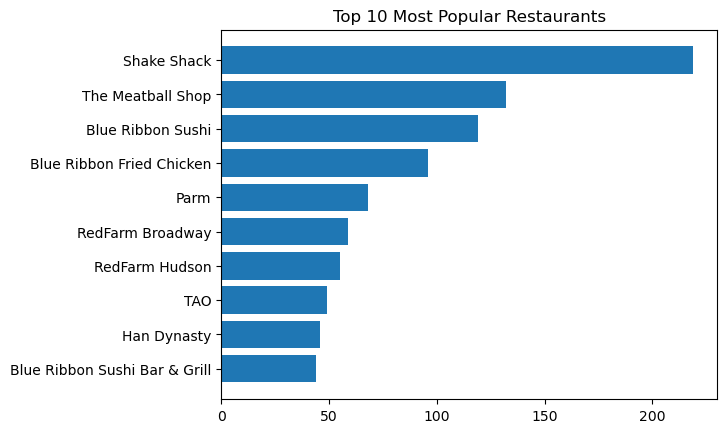

In [20]:
plt.barh(y=top_10_r.index,
         width = top_10_r.values);
plt.title("Top 10 Most Popular Restaurants")

In [21]:
foodhub["restaurant_name"].unique()

array(['Hangawi', 'Blue Ribbon Sushi Izakaya', 'Cafe Habana',
       'Blue Ribbon Fried Chicken', 'Dirty Bird to Go',
       'Tamarind TriBeCa', 'The Meatball Shop', 'Barbounia',
       'Anjappar Chettinad', 'Bukhara Grill',
       'Big Wong Restaurant \x8c_¤¾Ñ¼', 'Empanada Mama (closed)', 'Pylos',
       "Lucky's Famous Burgers", 'Shake Shack', 'Sushi of Gari',
       'RedFarm Hudson', 'Blue Ribbon Sushi',
       'Five Guys Burgers and Fries', 'Tortaria', 'Cafe Mogador',
       'Otto Enoteca Pizzeria', 'Vezzo Thin Crust Pizza',
       'Sushi of Gari 46', 'The Kati Roll Company', 'Klong',
       '5 Napkin Burger', 'TAO', 'Parm', 'Sushi Samba',
       'Haru Gramercy Park', 'Chipotle Mexican Grill $1.99 Delivery',
       'RedFarm Broadway', 'Cafeteria', 'DuMont Burger',
       "Sarabeth's East", 'Hill Country Fried Chicken', 'Bistango',
       "Jack's Wife Freda", "Mamoun's Falafel", 'Prosperity Dumpling',
       'Blue Ribbon Sushi Bar & Grill', 'Westville Hudson',
       'Blue Ribbon Br

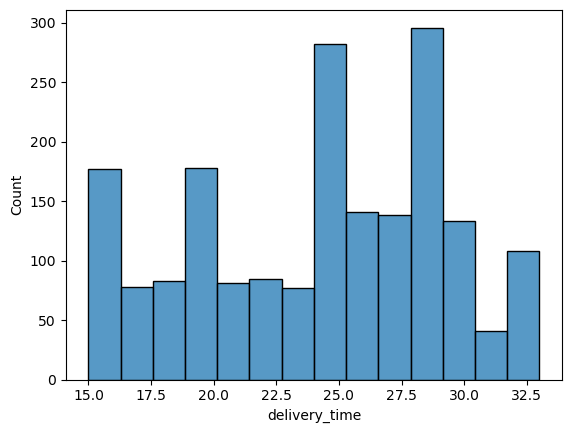

In [23]:
sns.histplot(foodhub["delivery_time"]);
plt.show()

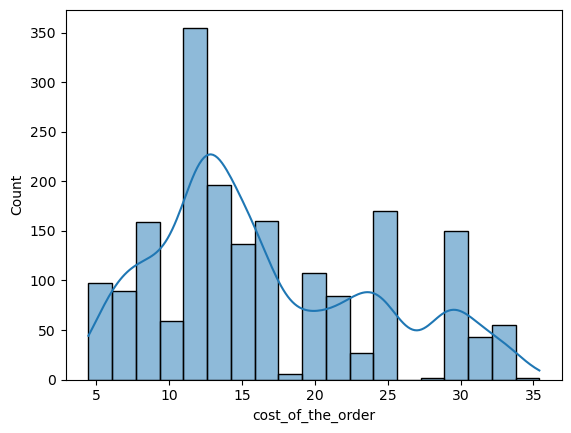

In [25]:
sns.histplot(foodhub["cost_of_the_order"], kde = True);
plt.show()    

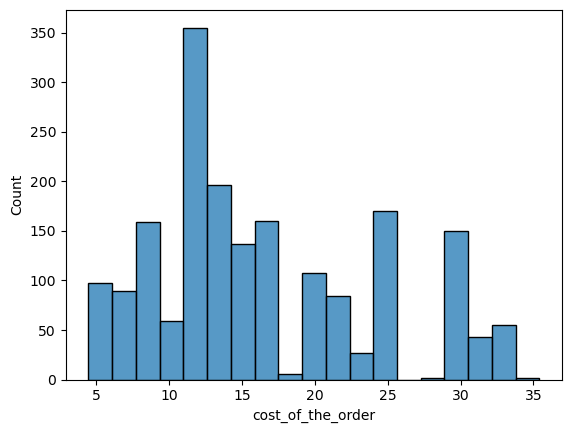

In [26]:
sns.histplot(foodhub["cost_of_the_order"]);
plt.show()    

In [27]:
foodhub.columns

Index(['order_id', 'customer_id', 'restaurant_name', 'cuisine_type',
       'cost_of_the_order', 'day_of_the_week', 'rating',
       'food_preparation_time', 'delivery_time'],
      dtype='object')

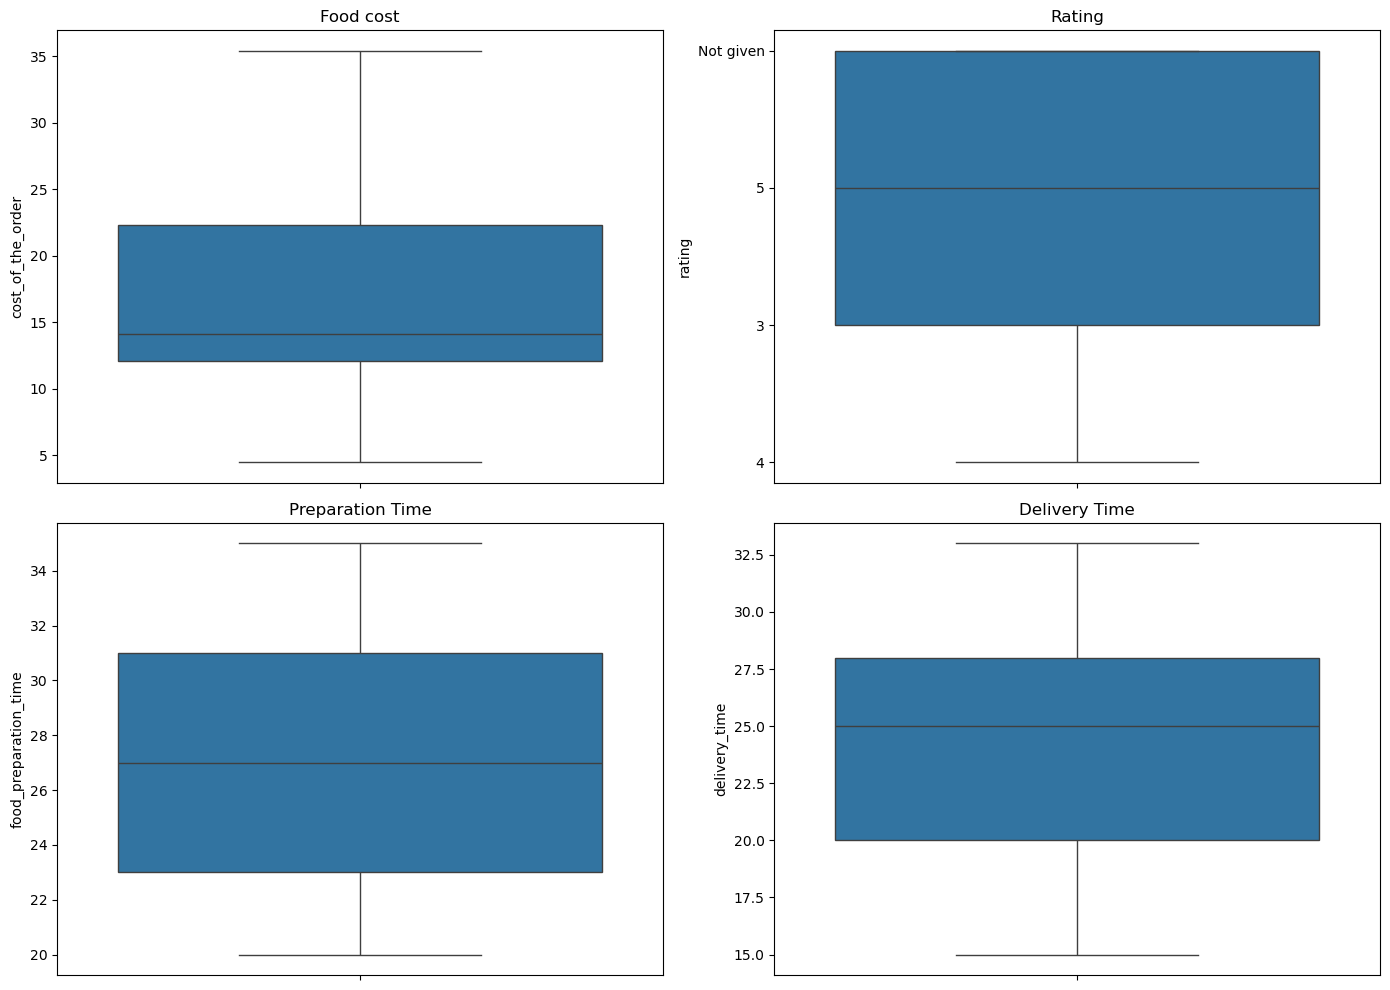

In [28]:
plt.figure(figsize=(14,10))
plt.subplot(2,2,1)
sns.boxplot(foodhub["cost_of_the_order"])
plt.title("Food cost")

plt.subplot(2,2,2)
sns.boxplot(foodhub["rating"])
plt.title("Rating")

plt.subplot(2,2,3)
sns.boxplot(foodhub["food_preparation_time"])
plt.title("Preparation Time")

plt.subplot(2,2,4)
sns.boxplot(foodhub["delivery_time"])
plt.title("Delivery Time")
    
plt.tight_layout()
plt.show()

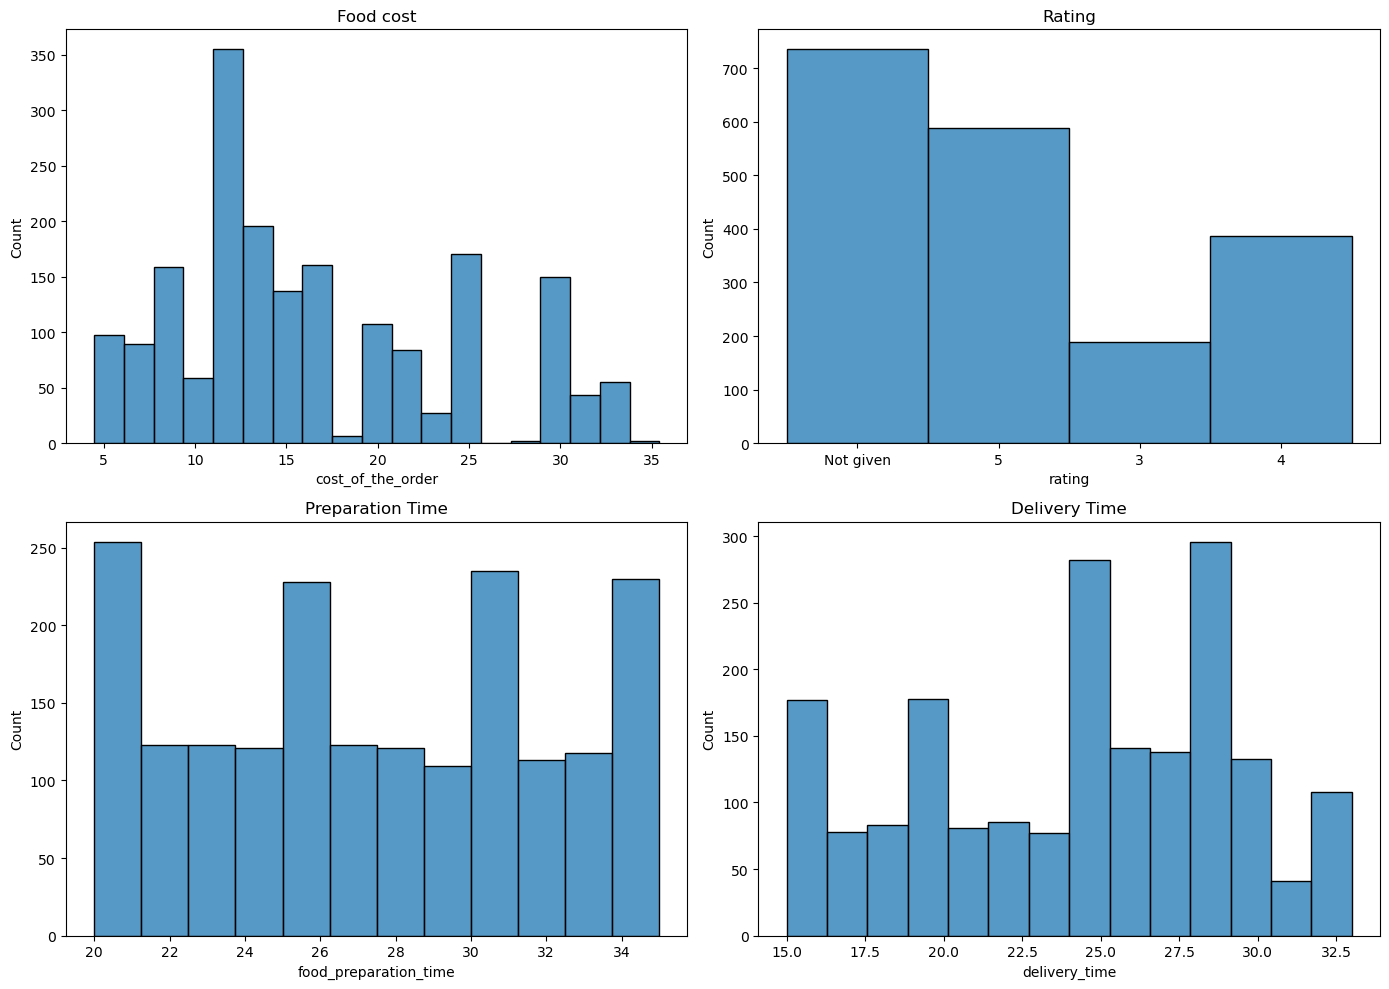

In [30]:
plt.figure(figsize=(14,10))
plt.subplot(2,2,1)
sns.histplot(foodhub["cost_of_the_order"])
plt.title("Food cost")

plt.subplot(2,2,2)
sns.histplot(foodhub["rating"])
plt.title("Rating")

plt.subplot(2,2,3)
sns.histplot(foodhub["food_preparation_time"])
plt.title("Preparation Time")

plt.subplot(2,2,4)
sns.histplot(foodhub["delivery_time"])
plt.title("Delivery Time")
    
plt.tight_layout()
plt.show()

In [31]:
foodhub.dtypes

order_id                   int64
customer_id                int64
restaurant_name           object
cuisine_type              object
cost_of_the_order        float64
day_of_the_week           object
rating                    object
food_preparation_time      int64
delivery_time              int64
dtype: object

### **Question 3**: Which are the top 5 restaurants in terms of the number of orders received?

The graph above shows that most of the orders

In [1]:
# Write the code here
# Feel free to add more cells


In [ ]:
#use groupby

In [32]:
top_5_r = foodhub["restaurant_name"].value_counts().nlargest(5)
top_5_r = top_5_r.sort_values(ascending = False)

In [33]:
top_5_r

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64

The top five restaurants are Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue RIbbon Fried Chicken, and Parm

### **Question 4**: Which is the most popular cuisine on weekends?

In [2]:
# Write the code here
# Feel free to add more cells

In [34]:
cuisine_and_day = foodhub.groupby("cuisine_type")[["day_of_the_week"]].value_counts()
cuisine_and_day

cuisine_type    day_of_the_week
American        Weekend            415
                Weekday            169
Chinese         Weekend            163
                Weekday             52
French          Weekend             13
                Weekday              5
Indian          Weekend             49
                Weekday             24
Italian         Weekend            207
                Weekday             91
Japanese        Weekend            335
                Weekday            135
Korean          Weekend             11
                Weekday              2
Mediterranean   Weekend             32
                Weekday             14
Mexican         Weekend             53
                Weekday             24
Middle Eastern  Weekend             32
                Weekday             17
Southern        Weekend             11
                Weekday              6
Spanish         Weekend             11
                Weekday              1
Thai            Weekend         

American cuisine is the most popular on weekends

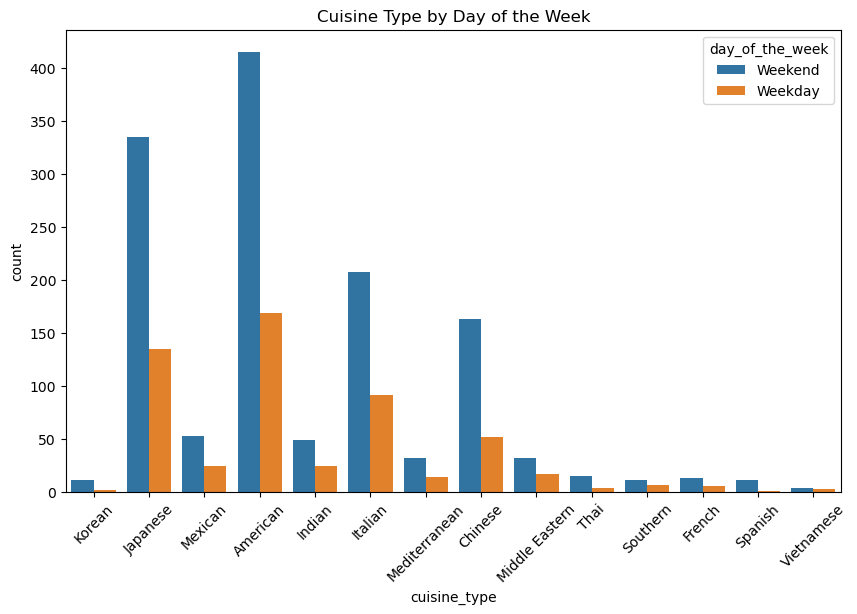

In [35]:
plt.figure(figsize=(10, 6))
sns.countplot(data=foodhub, x='cuisine_type', hue='day_of_the_week')
plt.xticks(rotation=45)
plt.title('Cuisine Type by Day of the Week')
plt.show()

American cuisine is the most popular on weekends

In [36]:
count_per_cuisine= foodhub.groupby(["cuisine_type", "day_of_the_week"], as_index=False) ["order_id"].count()\
                              .rename(columns= {"order_id":"counts"})\
                              .sort_values(by= "counts", ascending= False)\
                              .reset_index(drop = True)

In [37]:
count_per_cuisine[count_per_cuisine["day_of_the_week"] == "Weekend"].head(1)

,cuisine_type,day_of_the_week,counts
0,American,Weekend,415


### **Question 5**: What percentage of the orders cost more than 20 dollars?

In [3]:
# Write the code here
# Feel free to add more cells

In [38]:
foodhub.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [39]:
total_order_cost = foodhub["cost_of_the_order"].shape[0]
total_order_cost

1898

In [40]:
more_than_20 = foodhub[foodhub["cost_of_the_order"]>20].shape[0]

In [41]:
more_than_20

555

In [42]:
percentage_above_20 = (more_than_20 / total_order_cost) * 100

In [43]:
percentage_above_20
print(f"Approximately {percentage_above_20:.0f}% of the orders are more than 20 dollars.")

Approximately 29% of the orders are more than 20 dollars.


### **Question 6**: What is the mean order delivery time?

In [4]:
# Write the code here
# Feel free to add more cells

In [44]:
foodhub[["delivery_time"]].mean()

delivery_time    24.161749
dtype: float64

### **Question 7:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [5]:
# Write the code here
# Feel free to add more cells

In [45]:
customer_orders = foodhub.groupby('customer_id')['order_id'].count()
customer_orders = customer_orders.reset_index(name='num_orders')

top_customers = customer_orders.sort_values(by='num_orders', ascending=False)
top_3_customers = top_customers.head(3)

top_3_customers

,customer_id,num_orders
116,52832,13
84,47440,10
333,83287,9


In [47]:
top_3_customers = foodhub["customer_id"].value_counts().head(3).reset_index()
top_3_customers

,customer_id,count
0,52832,13
1,47440,10
2,83287,9


In [48]:
top_3_customers.columns=["customer_id", "number_of_orders"]
top_3_customers

,customer_id,number_of_orders
0,52832,13
1,47440,10
2,83287,9


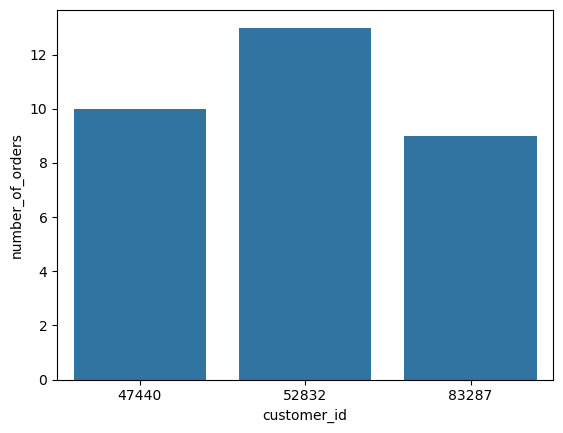

In [49]:
sns.barplot(data =top_3_customers, x="customer_id", y="number_of_orders" )
plt.show()

The top 3 most frequent customers have IDs 52832, 47440, and 83287

## Bivariate/Multivariate Analysis

### **Question 8**: Perform a bivariate/multivariate analysis to explore relationships between the important variables in the dataset.


In [ ]:
# Write the code here
# Feel free to add more cells

In [ ]:
sns.scatterplot(data = foodhub

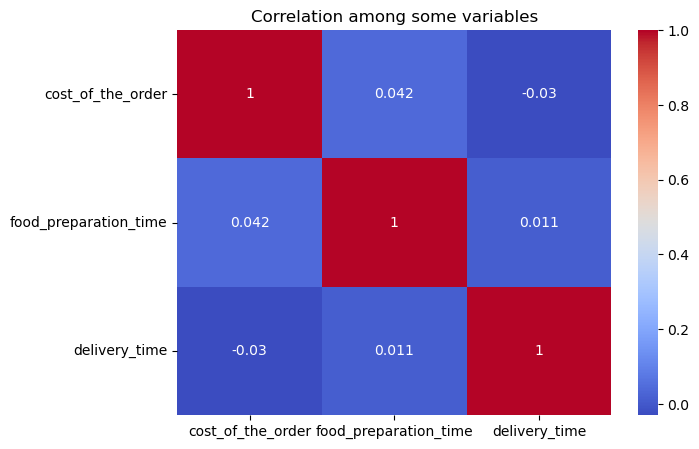

In [66]:
plt.figure(figsize=(7,5))
sns.heatmap(foodhub[["cost_of_the_order", "food_preparation_time", "delivery_time"]].corr(), annot=True, cmap = "coolwarm")
plt.title("Correlation among some variables")
plt.show()

### **Question 9:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer.

In [ ]:
# Write the code here
# Feel free to add more cells

In [74]:
# Group by restaurant
foodhub["rating"] = foodhub["rating"].replace('Not given', np.nan)
foodhub["rating"] = pd.to_numeric(foodhub["rating"])

restaurant_stats = foodhub.groupby("restaurant_name")["rating"].agg(["count", "mean"])

# Reset index for readability
restaurant_stats = restaurant_stats.reset_index()

# Filter based on conditions
eligible_restaurants = restaurant_stats[
    (restaurant_stats["count"] > 50) & 
    (restaurant_stats["mean"] > 4)
]

# Display result
eligible_restaurants.sort_values(by = "count", ascending = False)

,restaurant_name,count,mean
136,Shake Shack,133,4.278195
153,The Meatball Shop,84,4.511905
21,Blue Ribbon Sushi,73,4.219178
20,Blue Ribbon Fried Chicken,64,4.328125


### **Question 10:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders.

In [ ]:
# Write the code here
# Feel free to add more cells

In [61]:
def compute_revenue(cost):
    if cost > 20:
        return cost + 0.25
    elif cost > 5:
        return cost + 0.15
    else:
        return 0

total_revenue = foodhub["cost_of_the_order"].apply(compute_revenue).sum()
print(f"Total Net Revenue: {total_revenue:.2f} dollars")
        

Total Net Revenue: 31610.93 dollars


### **Question 11:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.)

In [ ]:
# Write the code here
# Feel free to add more cells

In [56]:
foodhub["total_time"] = foodhub["food_preparation_time"] +foodhub["delivery_time"]
foodhub.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,total_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20,45
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23,48
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28,51
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15,40
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24,49


In [60]:
over_60_min = foodhub[foodhub["total_time"]>60]
over_60_min.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,total_time
7,1477859,89574,Barbounia,Mediterranean,5.97,Weekday,3,33,30,63
10,1477895,143926,Big Wong Restaurant _¤¾Ñ¼,Chinese,5.92,Weekday,Not given,34,28,62
19,1477354,67487,Blue Ribbon Sushi,Japanese,16.20,Weekend,4,35,26,61
24,1476714,363783,Cafe Mogador,Middle Eastern,15.86,Weekday,Not given,32,29,61
54,1477760,130507,Jack's Wife Freda,Mediterranean,22.75,Weekend,3,35,29,64


In [ ]:
foodhub.shape[0]
over_60_min.shape[0]/100

### **Question 12:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends?

In [75]:
avg_on_both_types = foodhub.groupby("day_of_the_week")["delivery_time"].mean()
avg_on_both_types
print(f"The average delivery time is lower on weekends than on weekdays.")

The average delivery time is lower on weekends than on weekdays.


## Conclusion and Recommendations

### **Question 13:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.)

### Conclusions:
*  

### Recommendations:

*  

---